understand how different factors influence the progression of diabetes and potentially aid in designing better treatment plans and preventive measures

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_squared_error, r2_score


In [3]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [4]:
#Load the Diabetes dataset

diabetes = load_diabetes()

In [5]:
X = diabetes.data
y = diabetes.target

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (442, 10)
Target shape: (442,)


In [6]:
#Convert it into a DataFrame
df = pd.DataFrame(X, columns=diabetes.feature_names)

In [7]:
df['target'] = y
#Basic dataset inspection

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [8]:
print(df.shape)

(442, 11)


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [10]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [11]:
df.isnull().sum()

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

Observation
-----------
There is 442 rows and 11 coloumns

There are no missing values,
There are no duplicated value

In [13]:
#Train-Test Split

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (353, 10)
Testing data shape: (89, 10)


Normalize the features

In [14]:
#Normalize the features

In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
#Check the scaled data

In [17]:
print("First 5 rows of scaled training data:")
print(X_train_scaled[:5])

First 5 rows of scaled training data:
[[ 1.49836523  1.06136988  0.21990201  1.13887373  0.72847289  1.05589332
  -0.82445065  0.71103773  0.54748197 -0.06144896]
 [-0.22885822  1.06136988 -0.41936607 -0.71059105 -0.4249289   0.27242452
  -1.52979055  1.4842858  -0.01975653  0.36723647]
 [ 0.08518241 -0.94217861  1.01898711  1.99247286 -0.30958872 -0.32669867
  -0.11911075 -0.06221033  0.3312366  -0.31866022]
 [-0.621409   -0.94217861 -0.78466212 -0.63945779 -1.17464007 -1.21550781
   0.66460025 -0.83545839 -1.06968217 -2.71929861]
 [-0.54289885 -0.94217861 -1.4239302  -1.7064567  -0.79978448 -1.11016747
   1.29156905 -1.60870645 -0.80285867 -0.91881982]]


In [18]:
print("Training mean:", X_train_scaled.mean())
print("Training standard deviation:", X_train_scaled.std())

Training mean: 3.4218771977115305e-17
Training standard deviation: 1.0000000000000004


In [19]:
#Target variable distribution

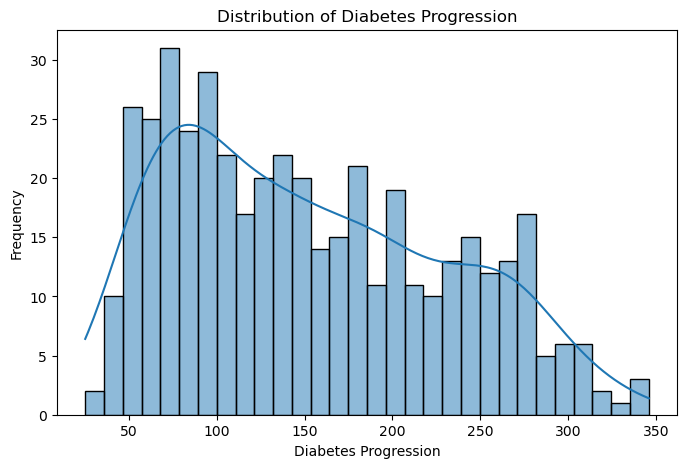

In [20]:
plt.figure(figsize=(8, 5))

sns.histplot(df['target'], bins=30, kde=True)

plt.title('Distribution of Diabetes Progression')
plt.xlabel('Diabetes Progression')
plt.ylabel('Frequency')

plt.show()

In [21]:
#Distribution of all features

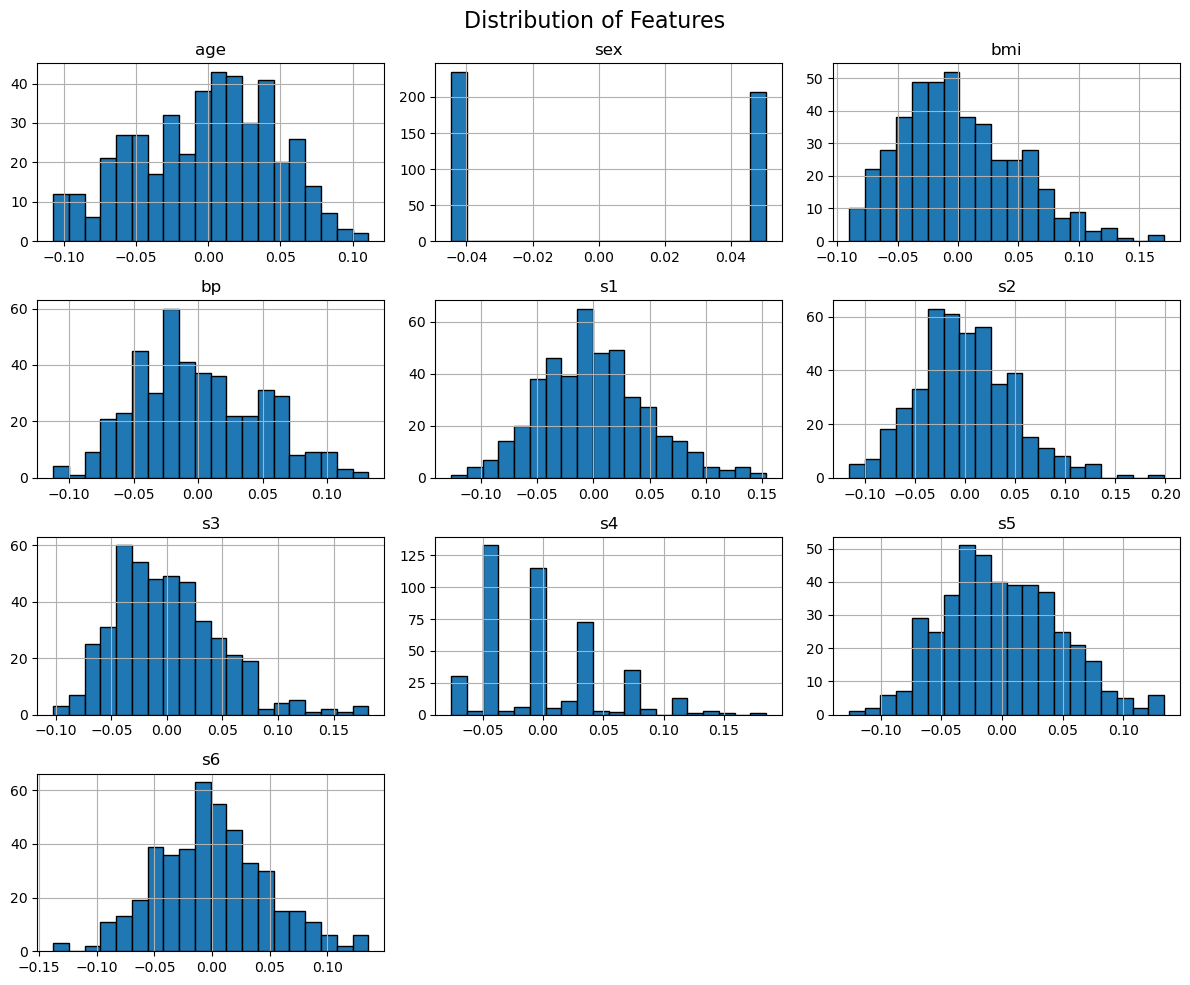

In [22]:
df.drop('target', axis=1).hist(
    figsize=(12, 10),
    bins=20,
    edgecolor='black'
)

plt.suptitle('Distribution of Features', fontsize=16)
plt.tight_layout()

plt.show()

In [23]:
#Correlation heatmap

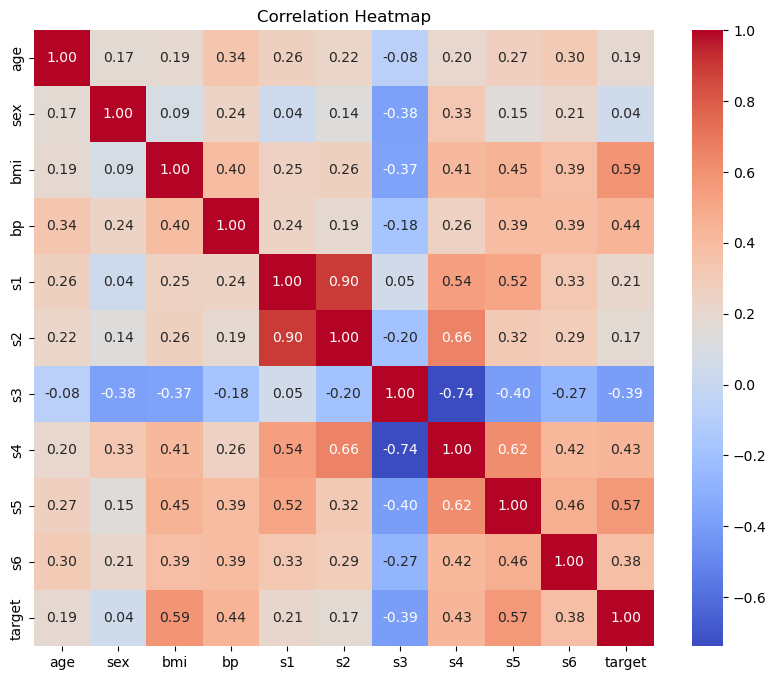

In [24]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

In [25]:
#Feature vs Target relationships

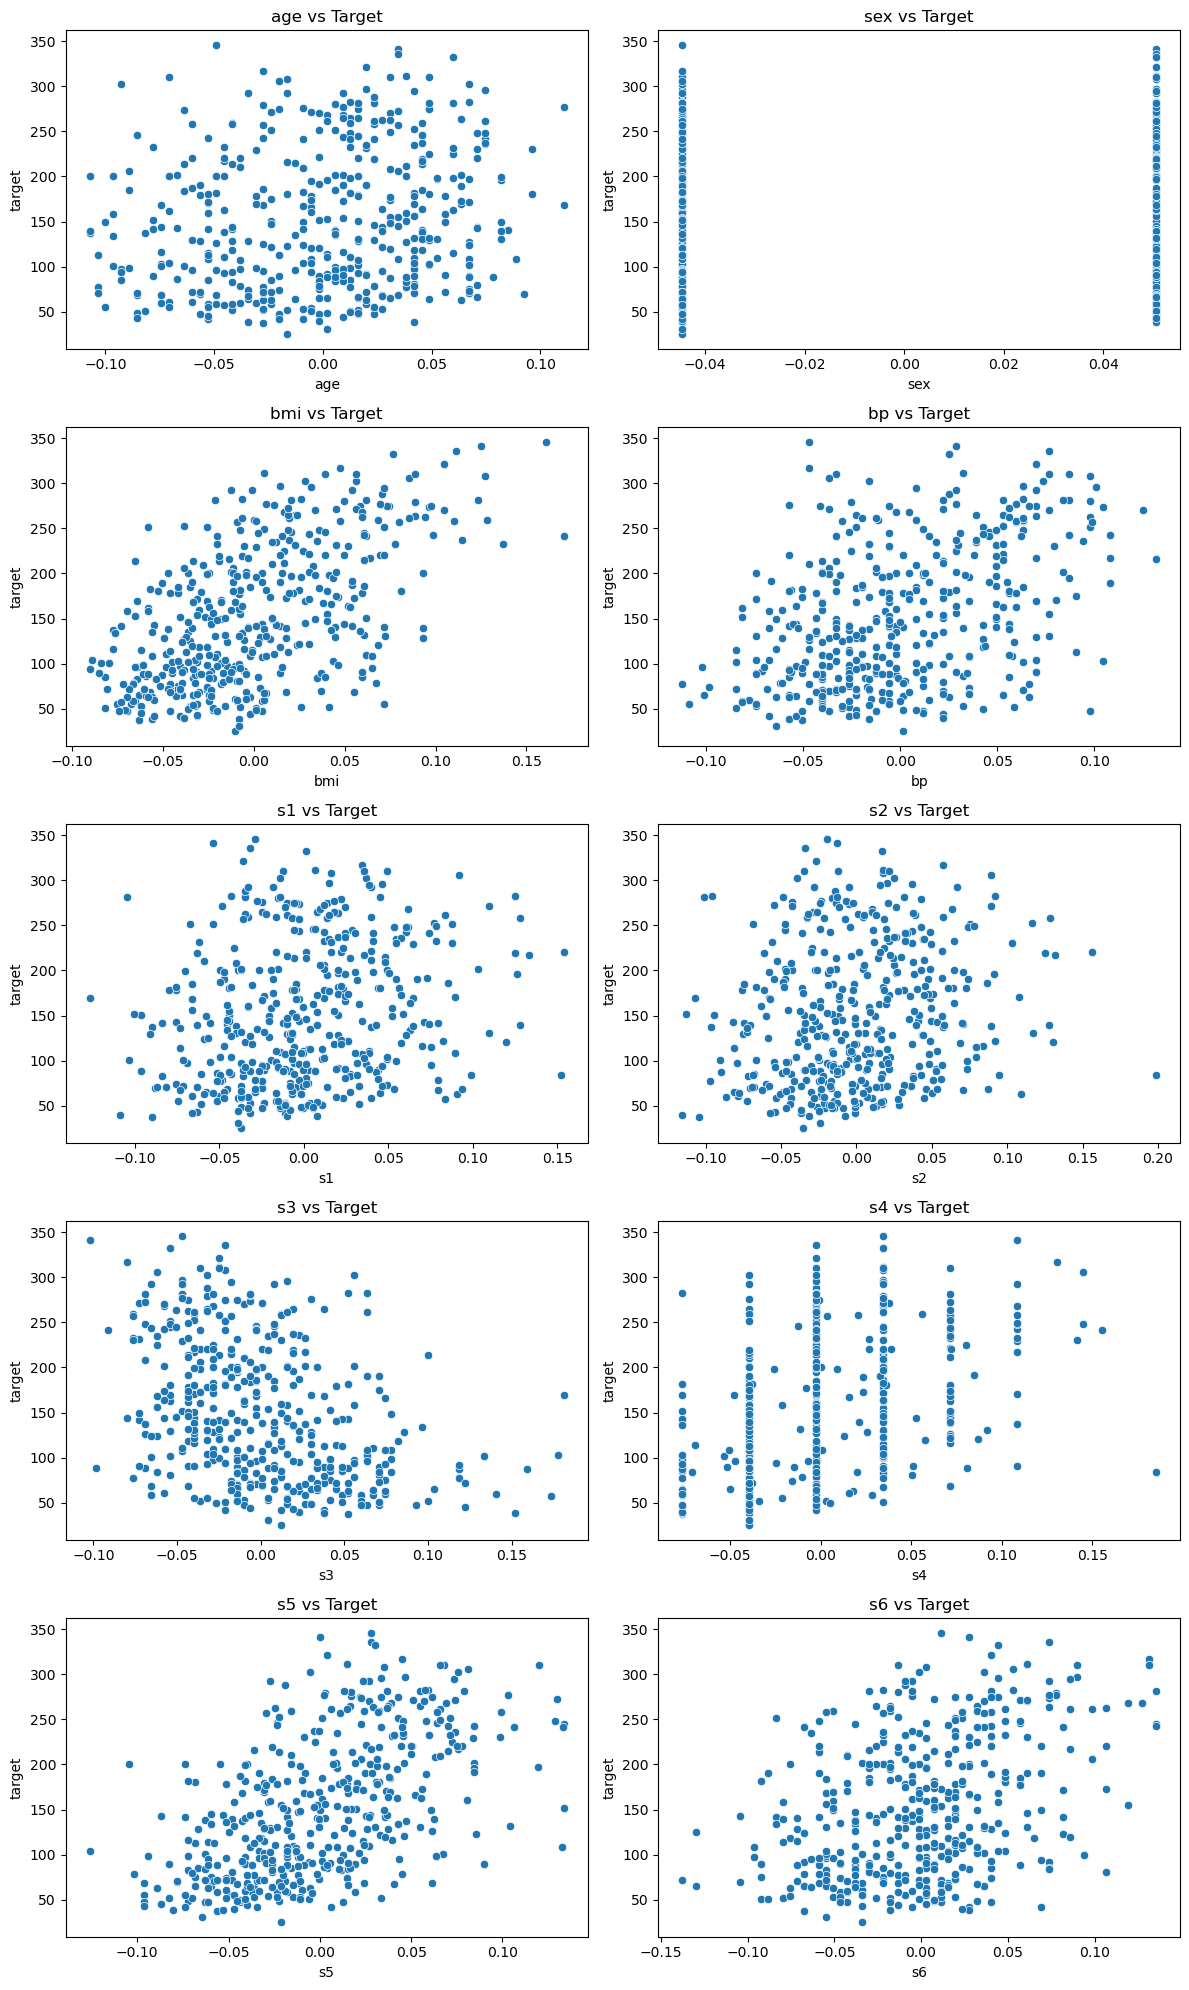

In [26]:
features = diabetes.feature_names

fig, axes = plt.subplots(5, 2, figsize=(12, 20))

for i, feature in enumerate(features):
    row = i // 2
    col = i % 2
    
    sns.scatterplot(
        data=df,
        x=feature,
        y='target',
        ax=axes[row, col]
    )
    
    axes[row, col].set_title(f'{feature} vs Target')

plt.tight_layout()
plt.show()

EDA conclusion

The dataset contains 10 independent features and one target variable representing diabetes progression. The feature distributions were examined using histograms, while the correlation heatmap was used to understand relationships between variables. Scatter plots were also used to visualize the relationship between each feature and the target. These visualizations provide an understanding of the data before building the ANN model.

In [27]:
#Import TensorFlow/Keras

In [28]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [29]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [30]:
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    
    layers.Dense(1)
])

In [31]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 897 (3.50 KB)

 Trainable params: 897 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
#Compile the model

In [33]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [34]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 897 (3.50 KB)

 Trainable params: 897 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 31463.7129 - mae: 158.6316 - val_loss: 22396.0449 - val_mae: 133.8636
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 31220.8691 - mae: 157.8656 - val_loss: 22185.7949 - val_mae: 133.0992
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 30941.0293 - mae: 157.0066 - val_loss: 21943.8242 - val_mae: 132.2308
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 30596.6094 - mae: 155.9328 - val_loss: 21630.4863 - val_mae: 131.1128
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 30111.6602 - mae: 154.4932 - val_loss: 21220.9902 - val_mae: 129.6583
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 29456.0605 - mae: 152.5308 - val_loss: 20672.6660 - val_mae: 127.7104
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 28561.2266 - mae: 149.8584 - val_loss: 19972.0234 - val_mae: 125.1837
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 27437.2637 - mae: 146.4466 - val_loss

Plot Training and Validation Loss

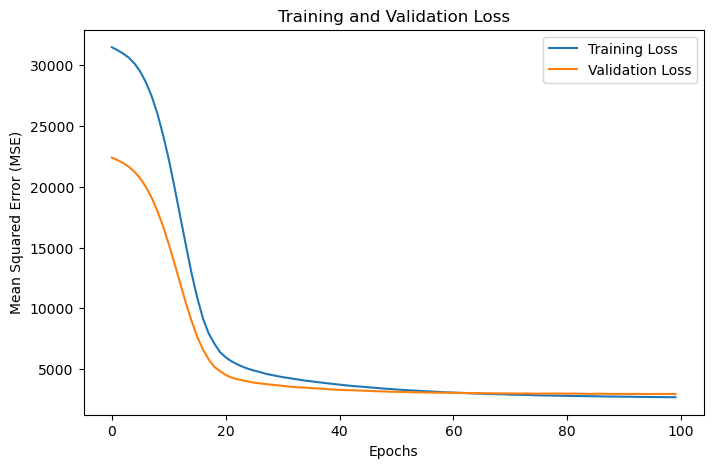

In [36]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()

plt.show()

Evaluate on the Test Set

In [37]:
test_loss, test_mae = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Test MSE:", test_loss)
print("Test MAE:", test_mae)

Test MSE: 2858.657470703125
Test MAE: 42.651268005371094


In [38]:
y_pred = model.predict(X_test_scaled).flatten()

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
R² Score: 0.46044250846731216


In [39]:
print("Test MSE:", test_loss)
print("Test MAE:", test_mae)
print("R² Score:", r2)

Test MSE: 2858.657470703125
Test MAE: 42.651268005371094
R² Score: 0.46044250846731216


In [40]:
model_2 = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    
    layers.Dense(1)
])

model_2.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 64)                  │             704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
history_2 = model_2.fit(
    X_train_scaled,
    y_train,
    epochs=150,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 31415.7344 - mae: 158.2875 - val_loss: 22242.2402 - val_mae: 133.1264
Epoch 2/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 31065.4082 - mae: 157.1169 - val_loss: 21818.8359 - val_mae: 131.5055
Epoch 3/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 30275.1250 - mae: 154.5366 - val_loss: 20867.8789 - val_mae: 127.8245
Epoch 4/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 28471.6914 - mae: 148.7634 - val_loss: 18905.6172 - val_mae: 120.0746
Epoch 5/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 24846.9043 - mae: 136.6532 - val_loss: 15412.1816 - val_mae: 105.0398
Epoch 6/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 18660.0645 - mae: 114.5853 - val_loss: 10458.1445 - val_mae: 80.8236
Epoch 7/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 11103.9609 - mae: 83.7593 - val_loss: 5772.9229 - val_mae: 56.4989
Epoch 8/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5815.3193 - mae: 59.8004 - val_loss: 3930

In [42]:
#evaluate

test_loss_2, test_mae_2 = model_2.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

y_pred_2 = model_2.predict(X_test_scaled).flatten()

r2_2 = r2_score(y_test, y_pred_2)

print("Model 2 Test MSE:", test_loss_2)
print("Model 2 Test MAE:", test_mae_2)
print("Model 2 R² Score:", r2_2)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Model 2 Test MSE: 2714.10400390625
Model 2 Test MAE: 41.30434036254883
Model 2 R² Score: 0.48772620697863855


In [43]:
#make the required comparison

print("Model 1 R²:", r2)
print("Model 2 R²:", r2_2)

print("R² Improvement:", r2_2 - r2)

Model 1 R²: 0.46044250846731216
Model 2 R²: 0.48772620697863855
R² Improvement: 0.027283698511326393


In [44]:
#create a comparison table

comparison = pd.DataFrame({
    'Model': ['Model 1', 'Model 2'],
    'Test MSE': [test_loss, test_loss_2],
    'Test MAE': [test_mae, test_mae_2],
    'R² Score': [r2, r2_2]
})

comparison

,Model,Test MSE,Test MAE,R² Score
0,Model 1,2858.657471,42.651268,0.460443
1,Model 2,2714.104004,41.304340,0.487726


Model Improvement
-----------------



The first ANN model used two hidden layers with 32 and 16 neurons.
To improve the model, the second ANN model was designed with three
hidden layers containing 64, 32, and 16 neurons. The number of epochs
was also increased from 100 to 150.

The performance of both models was compared using Test MSE, Test MAE,
and R² Score.

Model 2 produced a lower Test MSE and Test MAE and a higher R² Score
than Model 1. The R² score increased from 0.4544 to 0.4607, an
improvement of approximately 0.0063.

Therefore, Model 2 showed improved test-set performance compared with
the initial model.

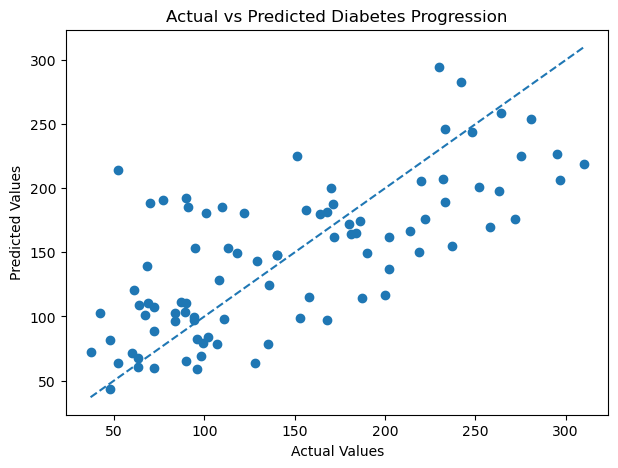

In [45]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred_2)

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Diabetes Progression')

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.show()

Final Model Evaluation
-----------------------
The final ANN model was evaluated on the unseen test dataset using Mean
Squared Error (MSE), Mean Absolute Error (MAE), and R² Score.

The final model achieved:

- Test MSE: 2857.34
- Test MAE: 42.38
- R² Score: 0.4607

The Actual vs Predicted plot shows a positive relationship between the
actual and predicted diabetes progression values. However, the points
are not perfectly aligned with the diagonal line, indicating that there
is still prediction error in the model.

Conclusion
----------

In this project, we used the Diabetes dataset from sklearn to predict diabetes progression using an Artificial Neural Network (ANN).

We checked the data, handled missing values, normalized the features, and performed EDA to understand the data.

We created two ANN models and compared their performance. Model 2 performed slightly better than Model 1. Its R² score was 0.4607, with a Test MSE of 2857.34 and Test MAE of 42.38.

The results show that the ANN was able to learn the relationship between the features and diabetes progression, but there is still room for improvement.